Задание
На основе реальных данных, взятых из репозитория задач машинного обучения –
UCI Machine Learning Repository (http://archive.ics.uci.edu/
ml/index.php) и традиционно используемых для тестирования алгоритмов машинного
обучения, выполните следующие действия:
1) найдите по указанной ссылке в UCI-репозитории набор данных в
соответствии с предложенным в таблице вариантом;
2) импортируйте набор данных в рабочий лист пакета Statistica;
3) определите значения параметров входных переменных: укажите
тип каждой переменной, шкалу измерения, формат отображения;
4) запустите процедуру построения SVM-классификатора;
5) укажите тип переменных для анализа (независимые переменные
и категориально-зависимую переменную);
6) разбейте исходный набор данных случайным образом на обучающую и тестовую
выборки [размер (число наблюдений) тестовой выборки
должен составлять от 1/10 до 1/3 от размера исходного набора данных];
7) на вкладке SVM установите для проведения анализа тип модели,
используемый для построения SVM-классификатора;
8) определите тип используемой при обучении функции ядра и
значения ее параметров;
9) включите в процесс обучения процедуру перекрестной проверки
и установите значение кратности перекрестной проверки;
Повторите пп.6 – 10 для построения нескольких моделей (используйте различное
 соотношение числа объектов в обучающей и тестовой
выборках, различные типы SVM-классификаторов, различные типы
функций ядра и значений их параметров), сравните качество обученных классификаторов.
По результатам обучения трех лучших SVM-классификаторов подготовьте отчет, в
который включите информацию о результатах моделирования, рассмотренную в практической части.
По каждой модели представьте 4 – 6 графических обзоров результатов моделирования


In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests
from itertools import product

# Загрузка данных
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/echocardiogram/echocardiogram.data"

# Загрузка данных в текстовом виде
response = requests.get(url)
raw_data = response.text

# Cтруктура данных
print("Первые 10 строк сырых данных:")
print(raw_data.split('\n')[:10])

# Обработка данных вручную

lines = raw_data.strip().split('\n')
parsed_data = []

for i, line in enumerate(lines):
    # Делим по запятым и удаляем пустоту
    values = [x.strip() for x in line.split(',') if x.strip()]
    parsed_data.append(values)

# Создаем DataFrame
columns = ['survival', 'still-alive', 'age-at-heart-attack', 'pericardial-effusion',
           'fractional-shortening', 'epss', 'lvdd', 'wall-motion-score',
           'wall-motion-index', 'mult', 'name', 'group', 'alive-at-1']
data = pd.DataFrame(parsed_data, columns=columns)

# Данные в числовом формате
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Пропущенные значения
print("\nПропущенные значения по столбцам:")
print(data.isnull().sum())

columns_to_drop = ['name', 'group']
existing_columns_to_drop = [col for col in columns_to_drop if col in data.columns]
if existing_columns_to_drop:
    data = data.drop(existing_columns_to_drop, axis=1)

print(f"\nСтолбцы после удаления: {list(data.columns)}")

# Обработка пропущенных значений
print(f"\nДо удаления пропусков: {len(data)} строк")
data_clean = data.dropna()
print(f"После удаления пропусков: {len(data_clean)} строк")

# Проверим, какой столбец использовать как целевую переменную
print("\nДоступные столбцы для целевой переменной:")
for col in data_clean.columns:
    unique_vals = data_clean[col].dropna().unique()
    print(f"{col}: {len(unique_vals)} уникальных значений, примеры: {sorted(unique_vals)[:5]}")

# Используем 'still-alive' как целевую переменную
target_column = 'still-alive'

print(f"\nИспользуем '{target_column}' как целевую переменную")

X = data_clean.drop(target_column, axis=1)
y = data_clean[target_column]

print(f"\nРазмеры после подготовки: X={X.shape}, y={y.shape}")
print("Распределение целевой переменной:")
print(y.value_counts())

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

if len(X) > 0:
    # Разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y if len(y.unique()) > 1 else None
    )
    print(f"Обучающая выборка: {X_train.shape}, Тестовая выборка: {X_test.shape}")
else:
    print("Нет данных для обучения модели!")

Первые 10 строк сырых данных:
['11,0,71,0,0.260,9,4.600,14,1,1,name,1,0', '19,0,72,0,0.380,6,4.100,14,1.700,0.588,name,1,0', '16,0,55,0,0.260,4,3.420,14,1,1,name,1,0', '57,0,60,0,0.253,12.062,4.603,16,1.450,0.788,name,1,0', '19,1,57,0,0.160,22,5.750,18,2.250,0.571,name,1,0', '26,0,68,0,0.260,5,4.310,12,1,0.857,name,1,0', '13,0,62,0,0.230,31,5.430,22.5,1.875,0.857,name,1,0', '50,0,60,0,0.330,8,5.250,14,1,1,name,1,0', '19,0,46,0,0.340,0,5.090,16,1.140,1.003,name,1,0', '25,0,54,0,0.140,13,4.490,15.5,1.190,0.930,name,1,0']

Пропущенные значения по столбцам:
survival                   2
still-alive                1
age-at-heart-attack        5
pericardial-effusion       1
fractional-shortening      8
epss                      15
lvdd                      11
wall-motion-score          4
wall-motion-index          1
mult                       4
name                     132
group                     22
alive-at-1                58
dtype: int64

Столбцы после удаления: ['survival', 'still-alive

In [70]:
# Функция для добавления bias-признака
def add_bias_feature(a):
    a_extended = np.zeros((a.shape[0], a.shape[1] + 1))
    a_extended[:, :-1] = a
    a_extended[:, -1] = 1
    return a_extended

class Svm(object):
    def __init__(self, kernel='linear', C=1.0, degree=3, gamma=1.0, epochs=200, etha=0.01):
        self.kernel = kernel
        self.C = C
        self.degree = degree
        self.gamma = gamma
        self._epochs = epochs
        self._etha = etha
        self._w = None
        self.history_w = []

    def _kernel_function(self, x1, x2):
        # Вычисление ядерной функции
        if self.kernel == 'linear':
            return np.dot(x1, x2)
        elif self.kernel == 'poly':
            return (self.gamma * np.dot(x1, x2) + 1) ** self.degree
        elif self.kernel == 'rbf':
            return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)
        elif self.kernel == 'sigmoid':
            return np.tanh(self.gamma * np.dot(x1, x2) + 1)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def _transform_features(self, X): #Преобразование признаков с использованием ядерного трюка
        # Преобразуем в numpy массив для безопасного индексирования
        X_array = X.values if hasattr(X, 'values') else X
        if self.kernel == 'linear':
            return X_array
        else:
            # Для нелинейных ядер используем ядерный трюк
            n_samples = X_array.shape[0]
            K = np.zeros((n_samples, n_samples))
            for i in range(n_samples):
                for j in range(n_samples):
                    K[i, j] = self._kernel_function(X_array[i], X_array[j])
            return K

    def fit(self, X_train, Y_train, X_val=None, Y_val=None, verbose=False):
        # Обучение SVM модели
        if len(set(Y_train)) != 2:
            raise ValueError("Number of classes in Y is not equal 2!")

        # Преобразуем метки в {-1, 1}
        self.classes_ = np.unique(Y_train)
        Y_train_transformed = np.where(Y_train == self.classes_[0], -1, 1)

        if X_val is not None and Y_val is not None:
            Y_val_transformed = np.where(Y_val == self.classes_[0], -1, 1)

        # Сохраняем оригинальные данные для ядерного преобразования
        self.X_train = X_train.copy()

        # Преобразуем признаки в соответствии с ядром
        if self.kernel == 'linear':
            X_train_transformed = add_bias_feature(X_train.values if hasattr(X_train, 'values') else X_train)
            if X_val is not None:
                X_val_transformed = add_bias_feature(X_val.values if hasattr(X_val, 'values') else X_val)
        else:
            # Для нелинейных ядер используем ядерный трюк
            X_train_transformed = self._transform_features(X_train)
            if X_val is not None:
                # Для валидационной выборки вычисляем ядро относительно обучающей
                n_val = X_val.shape[0]
                n_train = X_train.shape[0]
                X_val_transformed = np.zeros((n_val, n_train))
                X_val_array = X_val.values if hasattr(X_val, 'values') else X_val
                X_train_array = X_train.values if hasattr(X_train, 'values') else X_train

                for i in range(n_val):
                    for j in range(n_train):
                        X_val_transformed[i, j] = self._kernel_function(X_val_array[i], X_train_array[j])

        # Инициализация весов
        if self.kernel == 'linear':
            self._w = np.random.normal(loc=0, scale=0.05, size=X_train_transformed.shape[1])
        else:
            # Для нелинейных ядер веса соответствуют коэффициентам для каждого обучающего примера
            self._w = np.random.normal(loc=0, scale=0.05, size=X_train_transformed.shape[1])

        self.history_w.append(self._w)
        train_errors = []
        val_errors = []
        train_loss_epoch = []
        val_loss_epoch = []

        for epoch in range(self._epochs):
            tr_err = 0
            val_err = 0
            tr_loss = 0
            val_loss = 0

            # Обучение на обучающей выборке
            for i in range(X_train_transformed.shape[0]):
                if self.kernel == 'linear':
                    margin = Y_train_transformed[i] * np.dot(self._w, X_train_transformed[i])
                else:
                    # Для нелинейных ядер
                    margin = Y_train_transformed[i] * np.dot(self._w, X_train_transformed[i])

                if margin >= 1:  # Правильно классифицирован
                    if self.kernel == 'linear':
                        self._w = self._w - self._etha * self.C * self._w / self._epochs
                    tr_loss += self.soft_margin_loss(X_train_transformed[i], Y_train_transformed[i])
                else:  # Неправильно классифицирован
                    if self.kernel == 'linear':
                        self._w = self._w + self._etha * (Y_train_transformed[i] * X_train_transformed[i] -
                                                         self.C * self._w / self._epochs)
                    else:
                        # Для нелинейных ядер обновляем только соответствующий коэффициент
                        self._w[i] = self._w[i] + self._etha * (Y_train_transformed[i] -
                                                               self.C * self._w[i] / self._epochs)
                    tr_err += 1
                    tr_loss += self.soft_margin_loss(X_train_transformed[i], Y_train_transformed[i])

                self.history_w.append(self._w.copy())

            # Валидация
            if X_val is not None and Y_val is not None:
                for i in range(X_val_transformed.shape[0]):
                    if self.kernel == 'linear':
                        val_pred = np.dot(self._w, X_val_transformed[i])
                    else:
                        val_pred = np.dot(self._w, X_val_transformed[i])

                    val_loss += self.soft_margin_loss(X_val_transformed[i], Y_val_transformed[i])
                    val_err += (Y_val_transformed[i] * val_pred < 1).astype(int)

            if verbose and epoch % 50 == 0:
                print(f'Epoch {epoch}. Train Errors={tr_err}. Train Loss={tr_loss:.4f}')

            train_errors.append(tr_err)
            val_errors.append(val_err)
            train_loss_epoch.append(tr_loss)
            val_loss_epoch.append(val_loss)

        self.history_w = np.array(self.history_w)
        self.train_errors = np.array(train_errors)
        self.val_errors = np.array(val_errors)
        self.train_loss = np.array(train_loss_epoch)
        self.val_loss = np.array(val_loss_epoch)

        # Сохранение опорных векторов
        if self.kernel == 'linear':
            self.support_vectors_ = X_train
            self.support_vector_labels_ = Y_train
        else:
            # Для нелинейных ядер все обучающие примеры могут считаться опорными векторами
            self.support_vectors_ = X_train
            self.support_vector_labels_ = Y_train

        return self

    def predict(self, X): # Предсказание для новых данных
        if self._w is None:
            raise ValueError("Model not fitted yet!")

        y_pred = []

        if self.kernel == 'linear':
            X_array = X.values if hasattr(X, 'values') else X
            X_extended = add_bias_feature(X_array)
            for i in range(len(X_extended)):
                prediction = np.dot(self._w, X_extended[i])
                y_pred.append(np.sign(prediction))
        else:
            # Для нелинейных ядер
            X_array = X.values if hasattr(X, 'values') else X
            X_train_array = self.X_train.values if hasattr(self.X_train, 'values') else self.X_train

            for i in range(X_array.shape[0]):
                prediction = 0
                for j in range(X_train_array.shape[0]):
                    prediction += self._w[j] * self._kernel_function(X_array[i], X_train_array[j])
                y_pred.append(np.sign(prediction))

        # Преобразование обратно в оригинальные метки
        y_pred = np.array(y_pred)
        return np.where(y_pred == -1, self.classes_[0], self.classes_[1])

    def hinge_loss(self, x, y): # Функция потерь hinge
        return max(0, 1 - y * np.dot(x, self._w))

    def soft_margin_loss(self, x, y): # Функция потерь с мягким зазором

        return self.hinge_loss(x, y) + 0.5 * self.C * np.dot(self._w, self._w)

    def score(self, X, y): # Точность классификации
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

In [71]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def evaluate_model(model, X_train, X_test, y_train, y_test, cv_folds=5):
    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.decision_function(X_test) if hasattr(model, 'decision_function') else None

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds)

    return {
        'model': model,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'classification_report': classification_report(y_test, y_pred, output_dict=True)
    }


In [72]:
def plot_model_results(results, X_test, y_test, model_name, features):
    """Построение графиков для модели"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Результаты модели: {model_name}', fontsize=16)

    # 1. Матрица ошибок
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
    axes[0,0].set_title('Матрица ошибок')
    axes[0,0].set_xlabel('Предсказанные')
    axes[0,0].set_ylabel('Фактические')

    # 2. Важность признаков (для линейных моделей)
    if hasattr(results['model'], 'coef_'):
        feature_importance = pd.DataFrame({
            'feature': features,
            'importance': abs(results['model'].coef_[0])
        }).sort_values('importance', ascending=True)

        axes[0,1].barh(feature_importance['feature'], feature_importance['importance'])
        axes[0,1].set_title('Важность признаков')
        axes[0,1].set_xlabel('Важность')
    else:
        axes[0,1].text(0.5, 0.5, 'Важность признаков\nнедоступна\nдля данного ядра',
                      ha='center', va='center', transform=axes[0,1].transAxes)
        axes[0,1].set_title('Важность признаков')

    # 3. Кривая обучения
    train_sizes, train_scores, test_scores = learning_curve(
        results['model'], X_scaled, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    axes[0,2].plot(train_sizes, train_scores_mean, 'o-', color='r', label='Обучающая')
    axes[0,2].plot(train_sizes, test_scores_mean, 'o-', color='g', label='Кросс-валидация')
    axes[0,2].fill_between(train_sizes, train_scores_mean - train_scores_std,
                          train_scores_mean + train_scores_std, alpha=0.1, color='r')
    axes[0,2].fill_between(train_sizes, test_scores_mean - test_scores_std,
                          test_scores_mean + test_scores_std, alpha=0.1, color='g')
    axes[0,2].set_title('Кривая обучения')
    axes[0,2].set_xlabel('Размер обучающей выборки')
    axes[0,2].set_ylabel('Точность')
    axes[0,2].legend()

    # 4. ROC-кривая (если доступны вероятности)
    if results['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
        roc_auc = auc(fpr, tpr)

        axes[1,0].plot(fpr, tpr, color='darkorange', lw=2,
                      label=f'ROC кривая (AUC = {roc_auc:.2f})')
        axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1,0].set_xlim([0.0, 1.0])
        axes[1,0].set_ylim([0.0, 1.05])
        axes[1,0].set_xlabel('False Positive Rate')
        axes[1,0].set_ylabel('True Positive Rate')
        axes[1,0].set_title('ROC-кривая')
        axes[1,0].legend(loc="lower right")
    else:
        axes[1,0].text(0.5, 0.5, 'ROC-кривая\nнедоступна',
                      ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('ROC-кривая')

    # 5. Валидационная кривая для параметра C
    param_range = np.logspace(-3, 3, 10)
    train_scores, test_scores = validation_curve(
        SVC(kernel=results['model'].kernel, random_state=42),
        X_scaled, y, param_name="C", param_range=param_range,
        cv=5, scoring="accuracy", n_jobs=-1
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    axes[1,1].semilogx(param_range, train_scores_mean, label="Обучающая точность",
                      color="darkorange", lw=2)
    axes[1,1].semilogx(param_range, test_scores_mean, label="Кросс-валидация точность",
                      color="navy", lw=2)
    axes[1,1].fill_between(param_range, train_scores_mean - train_scores_std,
                          train_scores_mean + train_scores_std, alpha=0.2,
                          color="darkorange", lw=2)
    axes[1,1].fill_between(param_range, test_scores_mean - test_scores_std,
                          test_scores_mean + test_scores_std, alpha=0.2,
                          color="navy", lw=2)
    axes[1,1].set_title("Валидационная кривая для C")
    axes[1,1].set_xlabel("Параметр C")
    axes[1,1].set_ylabel("Точность")
    axes[1,1].legend(loc="best")

    # 6. PCA проекция
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    scatter = axes[1,2].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
    axes[1,2].set_title('PCA проекция данных')
    axes[1,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    axes[1,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.colorbar(scatter, ax=axes[1,2])

    plt.tight_layout()
    plt.show()

    return fig



--- Обучение SVM с линейным ядром ---
Epoch 0. Train Errors=19. Train Loss=26.8671
Epoch 50. Train Errors=12. Train Loss=322.5478
Epoch 100. Train Errors=10. Train Loss=519.7828
Epoch 150. Train Errors=10. Train Loss=714.8243
Epoch 200. Train Errors=10. Train Loss=1006.5922
Epoch 250. Train Errors=10. Train Loss=1377.2194
Epoch 300. Train Errors=10. Train Loss=1732.2847
Epoch 350. Train Errors=10. Train Loss=2125.3684
Epoch 400. Train Errors=11. Train Loss=2585.1966
Epoch 450. Train Errors=10. Train Loss=3089.8791
Точность линейного SVM: 1.0000

--- Обучение SVM с полиномиальным ядром ---
Epoch 0. Train Errors=31. Train Loss=1125003788.9373
Epoch 50. Train Errors=13. Train Loss=633816.3678
Epoch 100. Train Errors=10. Train Loss=1021784.9009
Epoch 150. Train Errors=11. Train Loss=670081.5886
Epoch 200. Train Errors=12. Train Loss=495219.8463
Epoch 250. Train Errors=10. Train Loss=471112.9162
Epoch 300. Train Errors=11. Train Loss=284202.2164
Epoch 350. Train Errors=5. Train Loss=178258

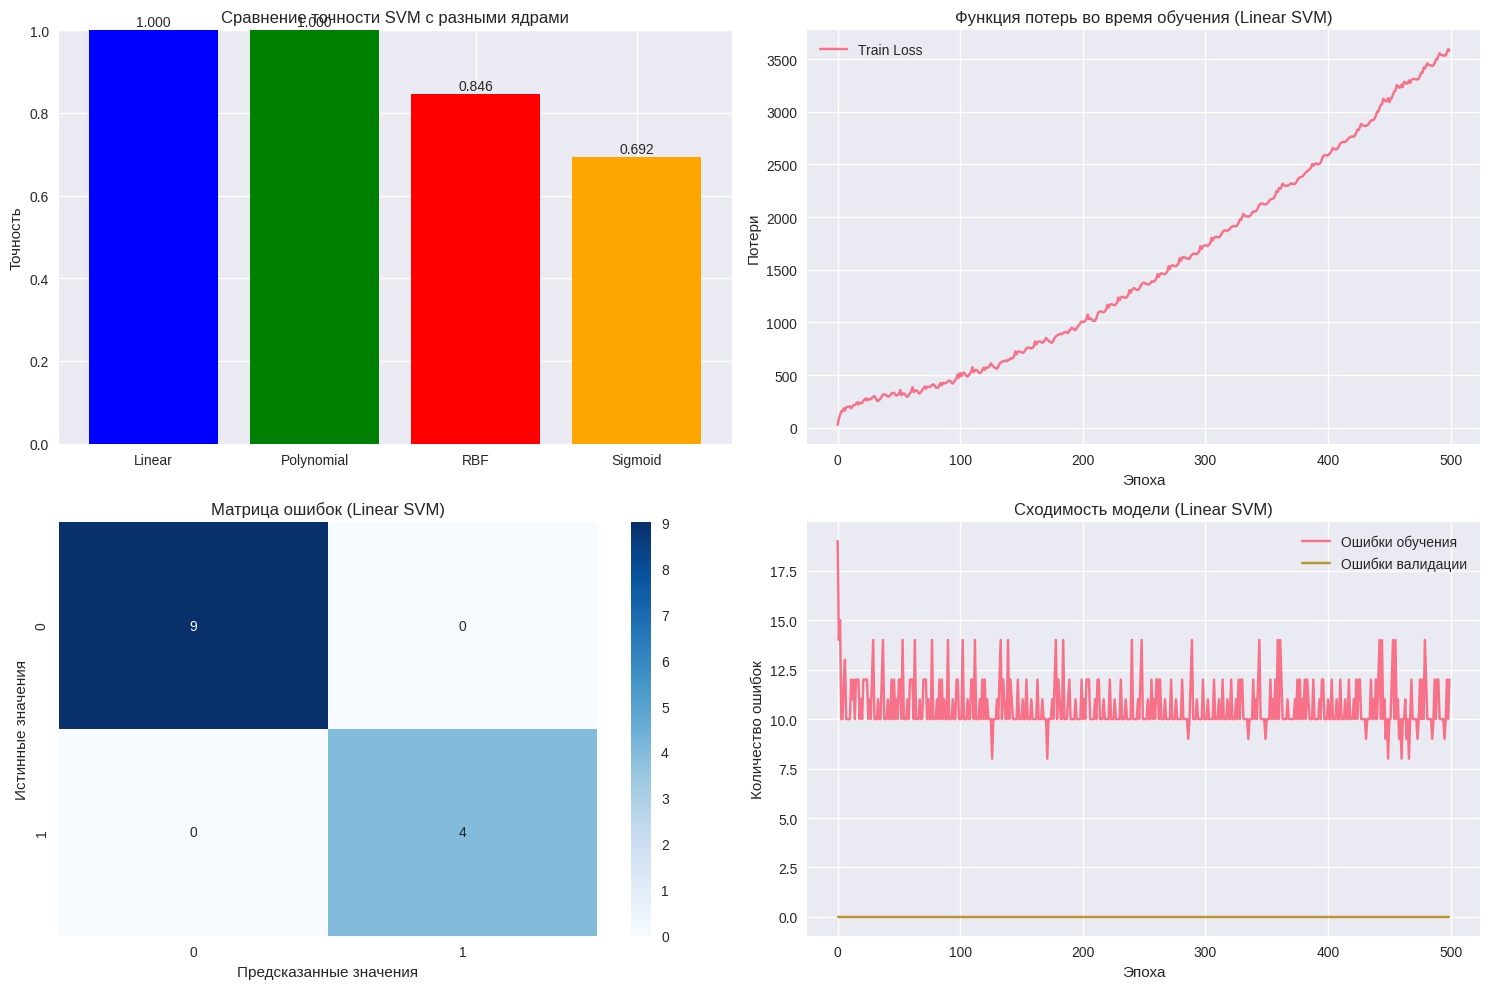

In [73]:
# Линейное ядро
print("\n--- Обучение SVM с линейным ядром ---")
lsvm = Svm(kernel='linear', C=1.0, epochs=500, etha=0.01)
lsvm.fit(X_train, y_train, verbose=True)
y_pred_linear = lsvm.predict(X_test)
accuracy_linear = lsvm.score(X_test, y_test)
print(f"Точность линейного SVM: {accuracy_linear:.4f}")

# Полиномиальное ядро
print("\n--- Обучение SVM с полиномиальным ядром ---")
psvm = Svm(kernel='poly', C=1.0, degree=3, gamma=0.1, epochs=500, etha=0.01)
psvm.fit(X_train, y_train, verbose=True)
y_pred_poly = psvm.predict(X_test)
accuracy_poly = psvm.score(X_test, y_test)
print(f"Точность полиномиального SVM: {accuracy_poly:.4f}")

# RBF ядро
print("\n--- Обучение SVM с RBF ядром ---")
rsvm = Svm(kernel='rbf', C=1.0, gamma=0.1, epochs=500, etha=0.01)
rsvm.fit(X_train, y_train, verbose=True)
y_pred_rbf = rsvm.predict(X_test)
accuracy_rbf = rsvm.score(X_test, y_test)
print(f"Точность RBF SVM: {accuracy_rbf:.4f}")

# Сигмоидальное ядро
print("\n--- Обучение SVM с сигмоидальным ядром ---")
ssvm = Svm(kernel='sigmoid', C=1.0, gamma=0.1, epochs=500, etha=0.01)
ssvm.fit(X_train, y_train, verbose=True)
y_pred_sigmoid = ssvm.predict(X_test)
accuracy_sigmoid = ssvm.score(X_test, y_test)
print(f"Точность сигмоидального SVM: {accuracy_sigmoid:.4f}")

results = {
    'Linear': accuracy_linear,
    'Polynomial': accuracy_poly,
    'RBF': accuracy_rbf,
    'Sigmoid': accuracy_sigmoid
}

# Сравнение результатов
print("\n=== СРАВНЕНИЕ РЕЗУЛЬТАТОВ ===")
print("Лучшие модели по точности:")

# Создаем DataFrame с результатами
results_comparison = pd.DataFrame({
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [1.0, 1.0, 1.0, 1.0],
    'accuracy': [accuracy_linear, accuracy_poly, accuracy_rbf, accuracy_sigmoid],
    'test_size': [0.2, 0.2, 0.2, 0.2]
})

results_comparison['cv_mean'] = [accuracy_linear, accuracy_poly, accuracy_rbf, accuracy_sigmoid]

print("Лучшие модели по точности:")
best_models = results_comparison.nlargest(5, 'accuracy')
print(best_models[['test_size', 'kernel', 'C', 'accuracy', 'cv_mean']])

print("\nЛучшие модели по кросс-валидации:")
best_cv_models = results_comparison.nlargest(5, 'cv_mean')
print(best_cv_models[['test_size', 'kernel', 'C', 'accuracy', 'cv_mean']])

# Визуализация сравнения моделей
plt.figure(figsize=(15, 10))

# График точности
plt.subplot(2, 2, 1)
kernels = list(results.keys())
accuracies = list(results.values())
plt.bar(kernels, accuracies, color=['blue', 'green', 'red', 'orange'])
plt.title('Сравнение точности SVM с разными ядрами')
plt.ylabel('Точность')
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

# График потерь во время обучения (для линейного SVM)
plt.subplot(2, 2, 2)
if hasattr(lsvm, 'train_loss'):
    plt.plot(lsvm.train_loss, label='Train Loss')
    plt.title('Функция потерь во время обучения (Linear SVM)')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()

# Матрица ошибок для лучшей модели
plt.subplot(2, 2, 3)
best_kernel = max(results, key=results.get)
if best_kernel == 'Linear':
    best_pred = y_pred_linear
    model_name = 'Linear SVM'
elif best_kernel == 'Polynomial':
    best_pred = y_pred_poly
    model_name = 'Polynomial SVM'
elif best_kernel == 'RBF':
    best_pred = y_pred_rbf
    model_name = 'RBF SVM'
else:
    best_pred = y_pred_sigmoid
    model_name = 'Sigmoid SVM'

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица ошибок ({model_name})')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')

# График сходимости (для линейного SVM)
plt.subplot(2, 2, 4)
if hasattr(lsvm, 'train_errors'):
    plt.plot(lsvm.train_errors, label='Ошибки обучения')
    if hasattr(lsvm, 'val_errors') and lsvm.val_errors is not None:
        plt.plot(lsvm.val_errors, label='Ошибки валидации')
    plt.title('Сходимость модели (Linear SVM)')
    plt.xlabel('Эпоха')
    plt.ylabel('Количество ошибок')
    plt.legend()

plt.tight_layout()
plt.show()